# SNL 코리아 롱폼 vs 숏폼 YouTube 영상 통계 수집
YouTube Data API v3로 SNL 코리아 채널의 영상 데이터를 수집해 MySQL DB에 저장합니다.

## 0. 환경 설정 및 라이브러리 로드

In [3]:
!pip install google-api-python-client

  Using cached google_api_python_client-2.196.0-py3-none-any.whl.metadata (7.0 kB)
  Using cached google_auth_httplib2-0.4.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached google_api_core-2.30.3-py3-none-any.whl.metadata (3.1 kB)
  Using cached uritemplate-4.2.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached googleapis_common_protos-1.75.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached proto_plus-1.28.0-py3-none-any.whl.metadata (2.2 kB)
Using cached google_api_python_client-2.196.0-py3-none-any.whl (15.2 MB)
Using cached google_api_core-2.30.3-py3-none-any.whl (173 kB)
Using cached google_auth_httplib2-0.4.0-py3-none-any.whl (9.5 kB)
Using cached googleapis_common_protos-1.75.0-py3-none-any.whl (300 kB)
Using cached proto_plus-1.28.0-py3-none-any.whl (50 kB)
Using cached uritemplate-4.2.0-py3-none-any.whl (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [google-api-python-client] [google-api-python-client]


In [3]:
import os
import re
import pandas as pd
from datetime import datetime, timezone
from dotenv import load_dotenv
from googleapiclient.discovery import build
from sqlalchemy import create_engine, text
import pymysql

load_dotenv()

API_KEY      = os.getenv('YOUTUBE_API_KEY')
MYSQL_HOST   = os.getenv('MYSQL_HOST', 'localhost')
MYSQL_USER   = os.getenv('MYSQL_USER', 'root')
MYSQL_PW     = os.getenv('MYSQL_PASSWORD', '')
MYSQL_DB     = os.getenv('MYSQL_DB', 'youtube_data')

assert API_KEY, '.env에 YOUTUBE_API_KEY가 없습니다.'

print(f'API KEY  : {API_KEY[:8]}...')
print(f'MySQL    : {MYSQL_USER}@{MYSQL_HOST}/{MYSQL_DB}')

API KEY  : AIzaSyCf...
MySQL    : root@localhost/youtube_data


## 1. YouTube API 클라이언트 초기화

In [4]:
def build_youtube_client(api_key: str):
    try:
        client = build('youtube', 'v3', developerKey=api_key)
        print('YouTube API 클라이언트 초기화 완료')
        return client
    except Exception as e:
        print(f'[ERROR] YouTube 클라이언트 초기화 실패: {e}')
        raise

youtube = build_youtube_client(API_KEY)

YouTube API 클라이언트 초기화 완료


## 2. MySQL DB 및 엔진 생성

In [5]:
def create_db_engine(host: str, user: str, pw: str, db: str):
    try:
        # DB가 없으면 먼저 생성
        conn = pymysql.connect(host=host, user=user, password=pw, charset='utf8mb4')
        with conn.cursor() as cur:
            cur.execute(f'CREATE DATABASE IF NOT EXISTS `{db}` CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci')
        conn.close()

        url = f'mysql+pymysql://{user}:{pw}@{host}/{db}?charset=utf8mb4'
        engine = create_engine(url)
        with engine.connect() as c:
            c.execute(text('SELECT 1'))
        print(f'MySQL 연결 성공: {user}@{host}/{db}')
        return engine
    except Exception as e:
        print(f'[ERROR] MySQL 연결 실패: {e}')
        raise

engine = create_db_engine(MYSQL_HOST, MYSQL_USER, MYSQL_PW, MYSQL_DB)

MySQL 연결 성공: root@localhost/youtube_data


## 3. SNL 코리아 채널 ID 조회

In [6]:
def search_channel(client, query: str, max_results: int = 5) -> list[dict]:
    try:
        res = client.search().list(
            q=query,
            type='channel',
            part='snippet',
            maxResults=max_results
        ).execute()
        channels = [
            {
                'channel_id': item['snippet']['channelId'],
                'title':      item['snippet']['title'],
                'desc':       item['snippet']['description'][:60]
            }
            for item in res.get('items', [])
        ]
        return channels
    except Exception as e:
        print(f'[ERROR] 채널 검색 실패: {e}')
        return []

channels = search_channel(youtube, 'SNL 코리아')
for i, ch in enumerate(channels):
    print(f'[{i}] {ch["title"]} | {ch["channel_id"]}')

[0] SNL Korea | UCOTfZwJ4WXANt5yssAYMiJg
[1] SNL영상모음 | UCCJRtdj-WGWC34OtFURv88w
[2] SNL 포에버 | UCcg-STmqv9m1b8rbNaMyk6g
[3] 쿠팡플레이 Coupang Play | UCjn-VbcIkAeXQKCmLJV8YwQ
[4] SNL 픽 | UC8TC3uiUigR-B_UE9MHHxMA


In [7]:
CHANNEL_ID = 'UCjn-VbcIkAeXQKCmLJV8YwQ'
print(f'선택된 채널: 쿠팡플레이 ({CHANNEL_ID})')

선택된 채널: 쿠팡플레이 (UCjn-VbcIkAeXQKCmLJV8YwQ)


## 4. 전체 영상 ID 수집

In [8]:
def get_uploads_playlist_id(client, channel_id: str) -> str:
    try:
        res = client.channels().list(
            id=channel_id,
            part='contentDetails'
        ).execute()
        return res['items'][0]['contentDetails']['relatedPlaylists']['uploads']
    except Exception as e:
        print(f'[ERROR] 플레이리스트 ID 조회 실패: {e}')
        raise


def get_all_video_ids(client, playlist_id: str) -> list[str]:
    video_ids = []
    next_page_token = None
    try:
        while True:
            res = client.playlistItems().list(
                playlistId=playlist_id,
                part='contentDetails',
                maxResults=50,
                pageToken=next_page_token
            ).execute()
            for item in res.get('items', []):
                video_ids.append(item['contentDetails']['videoId'])
            next_page_token = res.get('nextPageToken')
            if not next_page_token:
                break
    except Exception as e:
        print(f'[ERROR] 영상 ID 수집 중 오류 (수집된 수: {len(video_ids)}): {e}')
    return video_ids


playlist_id = get_uploads_playlist_id(youtube, CHANNEL_ID)
video_ids   = get_all_video_ids(youtube, playlist_id)
print(f'수집된 영상 수: {len(video_ids)}개')

수집된 영상 수: 3159개


## 5. 영상 상세 정보 수집 및 롱폼/숏폼 분류

In [9]:
import re

def parse_duration(duration_iso):
    if not duration_iso:
        return 0
    match = re.match(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?', duration_iso)
    if not match:
        return 0
    hours = int(match.group(1) or 0)
    minutes = int(match.group(2) or 0)
    seconds = int(match.group(3) or 0)
    return hours * 3600 + minutes * 60 + seconds

In [10]:
# def classify_content_type(duration_seconds: int, title: str) -> str:
#     if duration_seconds <= 60 or '#shorts' in title.lower() or '#short' in title.lower():
#         return 'shortform'
#     return 'longform'
def classify_content_type(duration_seconds: int, title: str) -> str:
    """#Shorts 태그 있거나 60초 이하 = 숏폼, 나머지 = 롱폼"""
    if '#shorts' in title.lower() or '#short' in title.lower() or duration_seconds <= 60:
        return 'shortform'
    else:
        return 'longform'

def fetch_video_details(client, ids: list[str]) -> list[dict]:
    records = []
    for i in range(0, len(ids), 50):
        chunk = ids[i:i+50]
        try:
            res = client.videos().list(
                id=','.join(chunk),
                part='snippet,statistics,contentDetails'
            ).execute()
            for item in res.get('items', []):
                snippet = item.get('snippet', {})
                stats   = item.get('statistics', {})
                content = item.get('contentDetails', {})

                duration_iso = content.get('duration', 'PT0S')
                duration_sec = parse_duration(duration_iso)

                title = snippet.get('title', '')
                records.append({
                    'video_id':        item['id'],
                    'title':           title,
                    'published_at':    snippet.get('publishedAt', ''),
                    'duration':        duration_iso,
                    'duration_seconds': duration_sec,
                    'view_count':      stats.get('viewCount'),
                    'like_count':      stats.get('likeCount'),
                    'comment_count':   stats.get('commentCount'),
                    'content_type':    classify_content_type(duration_sec, title),
                    'collected_at':    datetime.now(timezone.utc).isoformat()
                })
        except Exception as e:
            print(f'[ERROR] 영상 상세 수집 실패 (chunk {i}~{i+50}): {e}')
    return records


records = fetch_video_details(youtube, video_ids)
print(f'상세 수집 완료: {len(records)}개')

상세 수집 완료: 3159개


## 6. DataFrame 정리 (타입 변환 + fillna)

In [11]:
def build_dataframe(records: list[dict]) -> pd.DataFrame:
    df = pd.DataFrame(records)

    num_cols = ['duration_seconds', 'view_count', 'like_count', 'comment_count']
    str_cols = ['video_id', 'title', 'published_at', 'duration', 'content_type', 'collected_at']

    for col in num_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
    for col in str_cols:
        df[col] = df[col].fillna('')

    return df


df = build_dataframe(records)
print(df.dtypes)
print('\n롱폼/숏폼 분포:')
print(df['content_type'].value_counts())
df.head(3)

video_id            object
title               object
published_at        object
duration            object
duration_seconds     int64
view_count           int64
like_count           int64
comment_count        int64
content_type        object
collected_at        object
dtype: object

롱폼/숏폼 분포:
content_type
longform     1692
shortform    1467
Name: count, dtype: int64


,video_id,title,published_at,duration,duration_seconds,view_count,like_count,comment_count,content_type,collected_at
0,35FhwcPX5do,보기만 해도 아픔 🤕 [로맨스의 절댓값],2026-05-18T11:03:00Z,PT50S,50,6894,285,8,shortform,2026-05-18T16:18:20.674717+00:00
1,yTZ3acCwr6w,선생님 퇴학이라뇨... 우리 의주 지켜주세요 😣 [로맨스의 절댓값] 13-14화 예고편,2026-05-18T09:01:14Z,PT38S,38,4775,182,17,shortform,2026-05-18T16:18:20.674758+00:00
2,IPIlF7mvq8o,국어 선생님의 그림 🐍 [로맨스의 절댓값],2026-05-18T09:00:32Z,PT37S,37,6059,155,5,shortform,2026-05-18T16:18:20.674772+00:00


In [14]:
def add_engagement_rates(df):
    try:
        df = df.copy()
        df['like_rate'] = df.apply(
            lambda r: round(r['like_count'] / r['view_count'] * 100, 4)
            if r['view_count'] > 0 else 0.0,
            axis=1
        )
        df['comment_rate'] = df.apply(
            lambda r: round(r['comment_count'] / r['view_count'] * 100, 4)
            if r['view_count'] > 0 else 0.0,
            axis=1
        )
        print('like_rate / comment_rate 컬럼 추가 완료')
        print(df[['video_id', 'content_type', 'like_rate', 'comment_rate']].head())
        return df
    except Exception as e:
        print(f'[ERROR] 참여율 컬럼 추가 실패: {e}')
        raise


df = add_engagement_rates(df)

like_rate / comment_rate 컬럼 추가 완료
      video_id content_type  like_rate  comment_rate
0  35FhwcPX5do    shortform     4.1340        0.1160
1  yTZ3acCwr6w    shortform     3.8115        0.3560
2  IPIlF7mvq8o    shortform     2.5582        0.0825
3  GLQdvNi1aQk     longform     0.8942        0.0218
4  QmVTcqDEUGs     longform     2.8754        0.0000


## 7. MySQL 저장

In [15]:
def save_to_mysql(df: pd.DataFrame, engine, table: str = 'snl_videos'):
    try:
        df.to_sql(
            name=table,
            con=engine,
            if_exists='replace',
            index=False,
            chunksize=500
        )
        with engine.connect() as conn:
            count = conn.execute(text(f'SELECT COUNT(*) FROM `{table}`')).scalar()
        print(f'저장 완료: {count}개 레코드 → {MYSQL_DB}.{table}')
    except Exception as e:
        print(f'[ERROR] MySQL 저장 실패: {e}')
        raise


save_to_mysql(df, engine)

저장 완료: 3159개 레코드 → youtube_data.snl_videos


## 8. 저장 결과 확인

In [16]:
def load_summary(engine, table: str = 'snl_videos') -> pd.DataFrame:
    try:
        summary = pd.read_sql(
            f'''
            SELECT
                content_type,
                COUNT(*)                       AS video_count,
                ROUND(AVG(view_count))         AS avg_views,
                ROUND(AVG(like_count))         AS avg_likes,
                ROUND(AVG(comment_count))      AS avg_comments,
                ROUND(AVG(duration_seconds))   AS avg_duration_sec
            FROM `{table}`
            GROUP BY content_type
            ''',
            con=engine
        )
        return summary
    except Exception as e:
        print(f'[ERROR] 요약 조회 실패: {e}')
        raise


summary = load_summary(engine)
print('=== SNL 코리아 롱폼 vs 숏폼 요약 ===')
display(summary)

=== SNL 코리아 롱폼 vs 숏폼 요약 ===


,content_type,video_count,avg_views,avg_likes,avg_comments,avg_duration_sec
0,shortform,1467,308301.0,3246.0,66.0,45.0
1,longform,1692,471055.0,3542.0,297.0,236.0


In [17]:
def load_top_videos(engine, n: int = 10, table: str = 'snl_videos') -> pd.DataFrame:
    try:
        return pd.read_sql(
            f'''
            SELECT video_id, title, content_type, view_count, duration_seconds
            FROM `{table}`
            ORDER BY view_count DESC
            LIMIT {n}
            ''',
            con=engine
        )
    except Exception as e:
        print(f'[ERROR] TOP 영상 조회 실패: {e}')
        raise


top10 = load_top_videos(engine)
print('=== 조회수 TOP 10 ===')
display(top10)

=== 조회수 TOP 10 ===


,video_id,title,content_type,view_count,duration_seconds
0,FTTWG-9qSUw,SNL 코리아 | 곽동연 편 | 이수지 애드립에 놀란 곽동연 #shorts,shortform,17016641,59
1,QxL7_c1RjUU,직장인들 | 욕해본 적 없는 사람 | 쿠팡플레이 | 쿠팡,shortform,14948939,29
2,ReKRSTB5PK8,SNL 코리아 시즌2 신혜선 하이라이트 | 열일곱이지만 서른입니다ㅣ SNL 코리아 ...,longform,11050976,223
3,ge0G2TozNxg,SNL 코리아 | 육성재 편 | 연애 불변의 원칙 | 쿠팡플레이 | 쿠팡,longform,10617450,66
4,HjGF1ga1ijc,SNL 코리아 시즌3 | MZ오피스 전편 특별 편성 | 쿠팡플레이 | 쿠팡,longform,10102601,752
5,lhGXTnTaJxs,SNL 코리아 | 안재홍 편 | 스마일 클리닉 | 쿠팡플레이 | 쿠팡,longform,9445883,74
6,MpPoiAhoz2c,1분 쿠플 | 비상선언 | 소시오패스가 비행기 티켓을 끊을 때 | 쿠팡플레이 | 쿠...,shortform,8620998,58
7,PBTjJLrjKcA,SNL 코리아 인턴 기자 첫 번째 하이라이트 | Weekend Update 위켄드 ...,longform,8295527,179
8,Lfq9O0z-G9k,SNL 코리아 시즌3 | 채수빈 편 하이라이트 | 너와 나의 결혼수업 | 쿠팡플레이...,longform,7973011,293
9,pAV1l9qUtwo,SNL 코리아 시즌5 | 이유미 편 | 대꽃밭 연기 1티어 | 쿠팡플레이 코미디 쇼...,shortform,7630514,60


## 9. 콘텐츠 유형별 통계 시각화

In [18]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go


def plot_content_type_stats(summary: pd.DataFrame):
    try:
        order = ['shortform', 'longform']
        label_map = {'shortform': '숏폼', 'longform': '롱폼'}
        colors    = {'shortform': '#42B6FF', 'longform': '#FF7AC8'}

        df_plot = (
            summary
            .set_index('content_type')
            .reindex(order)
            .reset_index()
        )
        df_plot['label'] = df_plot['content_type'].map(label_map)
        bar_colors = [colors[ct] for ct in df_plot['content_type']]

        metrics = [
            ('avg_views',    '평균 조회수'),
            ('avg_likes',    '평균 좋아요수'),
            ('avg_comments', '평균 댓글수'),
        ]

        fig = make_subplots(
            rows=1, cols=3,
            subplot_titles=[m[1] for m in metrics],
            horizontal_spacing=0.1
        )

        for col_pos, (col_name, metric_label) in enumerate(metrics, start=1):
            fig.add_trace(
                go.Bar(
                    x=df_plot['label'],
                    y=df_plot[col_name],
                    marker_color=bar_colors,
                    text=df_plot[col_name].apply(lambda v: f'{v:,.0f}'),
                    textposition='outside',
                    showlegend=False,
                ),
                row=1, col=col_pos
            )

        fig.update_layout(
            title_text='SNL 코리아 — 콘텐츠 유형별 평균 지표',
            title_x=0.5,
            title_font_size=16,
            height=480,
            template='plotly_white',
            margin=dict(t=100, b=60)
        )
        fig.update_yaxes(tickformat=',')
        fig.show()

    except Exception as e:
        print(f'[ERROR] 시각화 실패: {e}')
        raise


plot_content_type_stats(summary)

[ERROR] 시각화 실패: tuple indices must be integers or slices, not str


TypeError: tuple indices must be integers or slices, not str

## 10. 콘텐츠 유형별 평균 참여율 시각화

In [15]:
df['like_rate'] = df['like_count'] / df['view_count'].replace(0, 1) * 100
df['comment_rate'] = df['comment_count'] / df['view_count'].replace(0, 1) * 100

df

,video_id,title,published_at,duration,duration_seconds,view_count,like_count,comment_count,content_type,collected_at,like_rate,comment_rate
0,GiFSqeMCyoQ,알바생이 너무 예뻐요 [봉주르빵집],2026-05-16T08:10:00Z,PT1M30S,90,2249,30,2,longform,2026-05-16T09:02:17.004708+00:00,1.333926,0.088928
1,t2k59GVbelY,재능이 남다른 직원들 [봉주르빵집] 2화 하이라이트,2026-05-16T08:01:01Z,PT5M23S,323,296,21,2,longform,2026-05-16T09:02:17.004812+00:00,7.094595,0.675676
2,ElmwGzX4ODk,내 학생은 내가 지킨다 [로맨스의 절댓값],2026-05-16T07:20:00Z,PT1M31S,91,2432,36,3,longform,2026-05-16T09:02:17.004827+00:00,1.480263,0.123355
3,3lZakE-KuUY,우리 담임선생님 멋있죠 ? [로맨스의 절댓값],2026-05-16T07:10:00Z,PT1M5S,65,3086,44,3,longform,2026-05-16T09:02:17.004839+00:00,1.425794,0.097213
4,vOMssyC3bxs,선생님 팔에 그림이 있다… 🫣🎨 [로맨스의 절댓값],2026-05-16T07:00:46Z,PT4M58S,298,2201,121,9,longform,2026-05-16T09:02:17.004853+00:00,5.497501,0.408905
...,...,...,...,...,...,...,...,...,...,...,...,...
3139,qjWrwDxQgBA,"⭐️쿠팡플레이 단독 공개⭐️ 연애 상담 하고 싶다면 봐야하는 드라마, 러브 라이프 ...",2021-04-14T09:00:31Z,PT1M46S,106,3901,13,1,longform,2026-05-16T09:02:33.266905+00:00,0.333248,0.025634
3140,utxptsZ6bjI,"⭐️쿠팡플레이 단독 공개⭐️ 연애가 고민이라면 봐야하는 드라마, 러브 라이프 | 러...",2021-04-13T09:52:21Z,PT31S,31,6224,27,3,shortform,2026-05-16T09:02:33.266921+00:00,0.433805,0.048201
3141,WF4KrZZ_Vmk,귀신 들린 집만 취급하는 부동산 이야기 | 대박부동산 X 쿠팡플레이 예고편,2021-04-07T11:00:11Z,PT42S,42,6375,37,2,shortform,2026-05-16T09:02:33.266936+00:00,0.580392,0.031373
3142,c3QPv1wUv9k,부동산에서 퇴마를 하게 된 이유 | 대박부동산 X 쿠팡플레이 예고편,2021-04-07T09:00:27Z,PT35S,35,3311,33,1,shortform,2026-05-16T09:02:33.266951+00:00,0.996678,0.030202


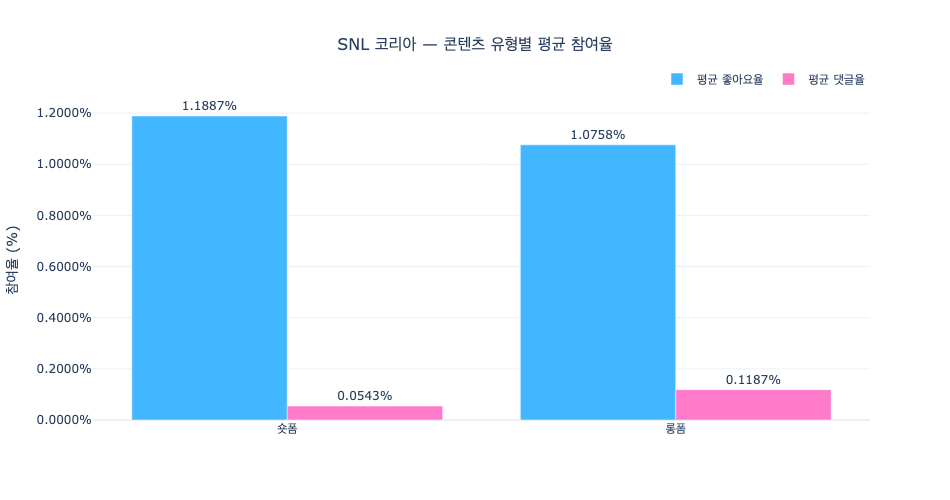

In [16]:
import plotly.graph_objects as go


def plot_engagement_rates(df):
    try:
        order     = ['shortform', 'longform']
        label_map = {'shortform': '숏폼', 'longform': '롱폼'}

        eng = (
            df.groupby('content_type')[['like_rate', 'comment_rate']]
            .mean()
            .reindex(order)
            .reset_index()
        )
        eng['label'] = eng['content_type'].map(label_map)

        fig = go.Figure()

        fig.add_trace(go.Bar(
            name='평균 좋아요율',
            x=eng['label'],
            y=eng['like_rate'].round(4),
            marker_color='#42B6FF',
            text=eng['like_rate'].apply(lambda v: f'{v:.4f}%'),
            textposition='outside'
        ))

        fig.add_trace(go.Bar(
            name='평균 댓글율',
            x=eng['label'],
            y=eng['comment_rate'].round(4),
            marker_color='#FF7AC8',
            text=eng['comment_rate'].apply(lambda v: f'{v:.4f}%'),
            textposition='outside'
        ))

        fig.update_layout(
            title_text='SNL 코리아 — 콘텐츠 유형별 평균 참여율',
            title_x=0.5,
            title_font_size=16,
            barmode='group',
            yaxis_title='참여율 (%)',
            # width=500,
            height=500,
            template='plotly_white',
            legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
        )
        fig.update_yaxes(tickformat='.4f', ticksuffix='%')
        fig.show()

    except Exception as e:
        print(f'[ERROR] 참여율 시각화 실패: {e}')
        raise


plot_engagement_rates(df)

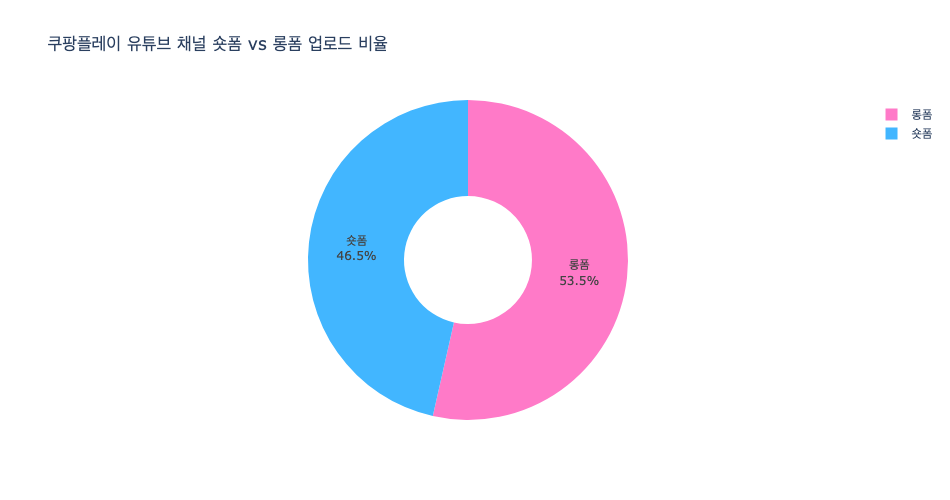

In [17]:
# 쿠팡플레이 포맷 분포 파이차트
format_counts = df['content_type'].value_counts()

fig = go.Figure(go.Pie(
    labels=['숏폼', '롱폼'],
    values=[format_counts.get('shortform', 0), format_counts.get('longform', 0)],
    marker=dict(colors=['#42B6FF', '#FF7AC8']),
    textinfo='label+percent',
    hole=0.4
))
fig.update_layout(
    title='쿠팡플레이 유튜브 채널 숏폼 vs 롱폼 업로드 비율',
    template='plotly_white',
    height=500
)
fig.show()

In [19]:
df.to_csv('/Users/jeong-eunseo/Data/teamProject/PM_dataproject/YOUTUBE_API/collectors/coupangplay/coupangplay_youtube.csv', index=False, encoding='utf-8-sig')
print('CSV 저장 완료')

CSV 저장 완료
